# DATA수집 (dollor index)

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

In [ ]:
# 달러 인덱스는 유로, 엔, 파운드 등 주요 6개국 통화 대비 달러의 가치를 나타내는 지표
# 티커(Ticker)인 'DX-Y.NYB'는 뉴욕 정기 거래소에서 산출되는 달러 인덱스 값을 의미
# 유로(57.6%), 일본 엔(13.6%), 영국 파운드(11.9%), 캐나다 달러(9.1%), 스웨덴 크로나(4.2%), 스위스 프랑(3.6%) 순의 비중으로 구성되어 있음
ticker_symbol = "DX-Y.NYB"

end_date = datetime.now().strftime('%Y-%m-%d')
start_date = (datetime.now() - timedelta(days=5*365)).strftime('%Y-%m-%d')

print(f"데이터 수집 기간: {start_date} 부터 {end_date} 까지")

데이터 수집 기간: 2021-03-27 부터 2026-03-26 까지


In [ ]:
raw_data = yf.download(ticker_symbol, start=start_date, end=end_date)

# Date(날짜), Open(시가), High(고가), Low(저가), Close(종가), Adj Close(수정종가), Volume(거래량)
raw_data.head()

/tmp/ipykernel_2663/3880451686.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_data = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB
Date,,,,,
2021-03-29,92.940002,92.959999,92.720001,92.720001,0
2021-03-30,93.300003,93.349998,92.879997,92.910004,0
2021-03-31,93.230003,93.440002,92.989998,93.239998,0
2021-04-01,92.930000,93.339996,92.879997,93.220001,0
2021-04-05,92.599998,93.110001,92.540001,93.010002,0


# 5년간의 달러 인덱스 변화

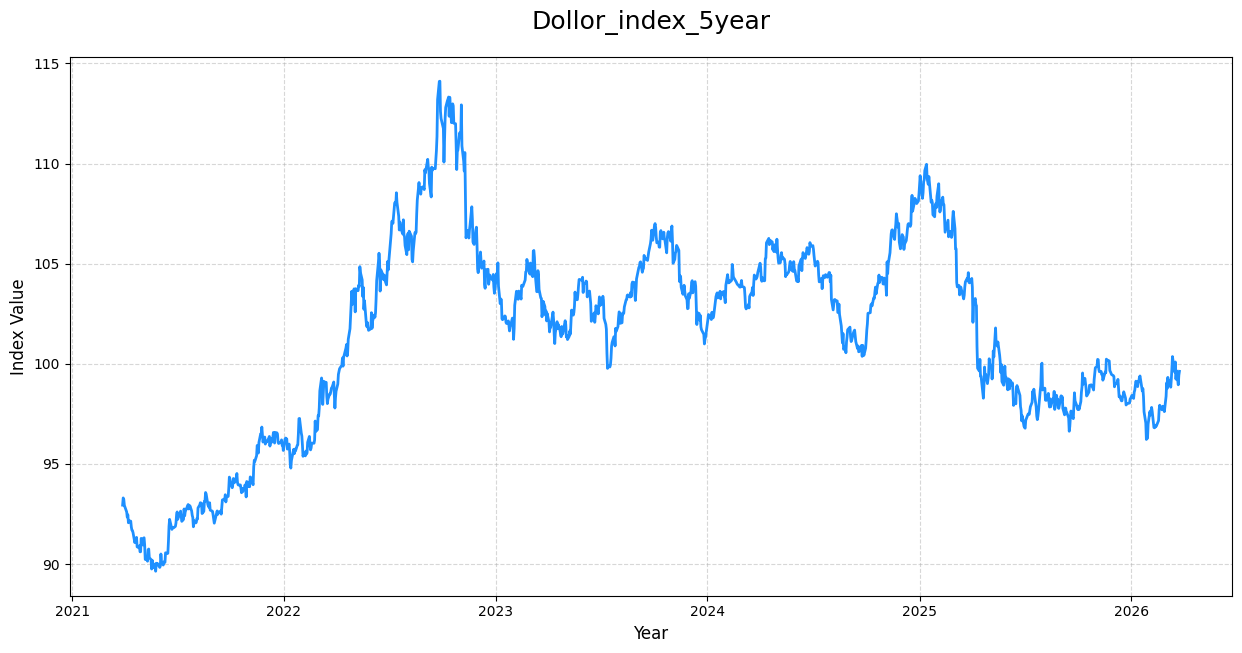

'DXY_5Year_Data_20260326.csv'저장


In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(dxy_processed.index, dxy_processed['Close'], color='dodgerblue', linewidth=2)
plt.title('Dollor_index_5year', fontsize=18, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Index Value', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

file_name = f"DXY_5Year_Data_{datetime.now().strftime('%Y%m%d')}.csv"
dxy_processed.to_csv(file_name)
print(f"'{file_name}'저장")

## 그래프 분석 의견
- 달러 인덱스가 왜 상승하고 하락하는지에 대한 뉴스 정보 데이터와 나스닥 지표가 필요 할 것 같다고 생각하고 있음
- 달러 인덱스가 영향을 받는 주요 화폐들의 환율과 FOMC(연준) 발표 자료를 살펴 봐야된다고 생각됨

# 데이터 수집 (원화 환율)

In [ ]:
# 환율 데이터 수집
krw_ticker = "USDKRW=X"

# 환율과 달러 인덱스의 날짜는 같게 해야 비교가 될 것 같음.
krw_raw_data = yf.download(krw_ticker, start=start_date, end=end_date)

# 종가 데이터만 따로 때내어서 그래프 그릴때 쓰기
krw_data = krw_raw_data[['Close']].copy()
krw_data.columns = ['KRW_Rate'] # 컬럼 이름을 KRW_Rate로 변경

# 친구의견 : dropna나 log return 를 써보는걸 추천하고 있음
krw_data = krw_data.ffill()

krw_data.tail()

/tmp/ipykernel_2663/1338084078.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  krw_raw_data = yf.download(krw_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


,KRW_Rate
Date,
2026-03-19,1505.250000
2026-03-20,1489.839966
2026-03-23,1504.209961
2026-03-24,1485.359985
2026-03-25,1497.310059


# dollor index & KRW 5 year 그래프

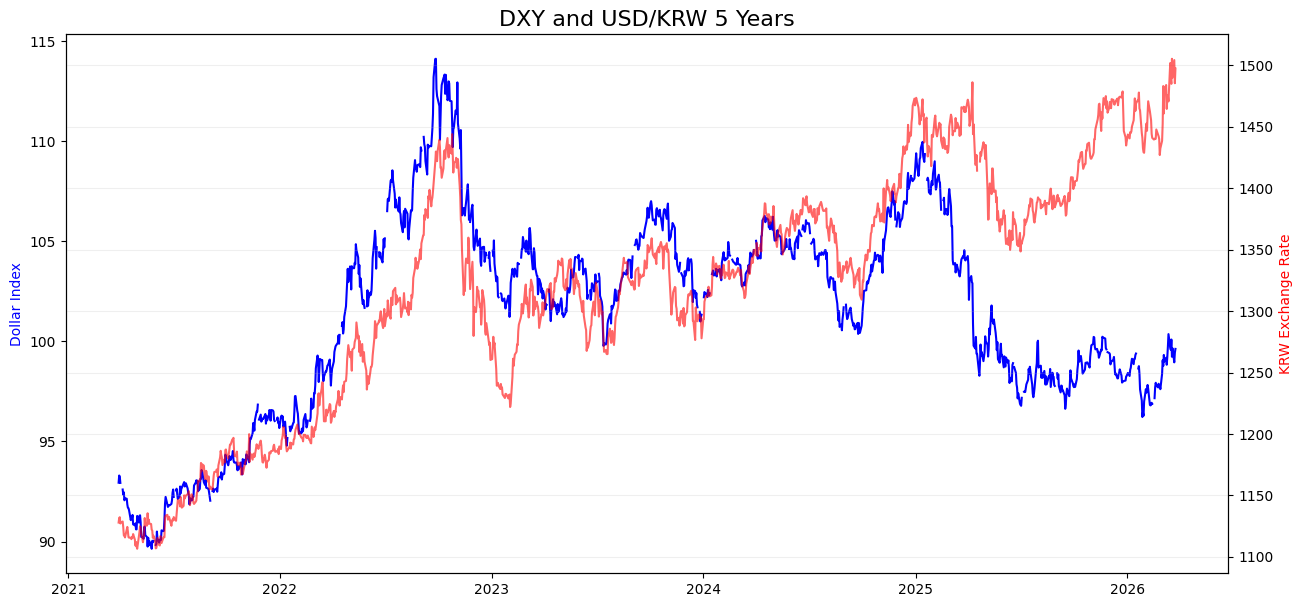

In [ ]:
combined_df = pd.concat([dxy_processed, krw_data], axis=1)
combined_df.columns = ['DXY_Index', 'USD_KRW']


combined_df.head()

fig, ax1 = plt.subplots(figsize=(15, 7))

# 달러 인덱스 (왼쪽)
ax1.plot(combined_df.index, combined_df['DXY_Index'], color='blue', label='Dollar Index (Left)')
ax1.set_ylabel('Dollar Index', color='blue')

# 환율 (오른쪽)
ax2 = ax1.twinx()
ax2.plot(combined_df.index, combined_df['USD_KRW'], color='red', alpha=0.6, label='USD/KRW (Right)')
ax2.set_ylabel('KRW Exchange Rate', color='red')

plt.title('DXY and USD/KRW 5 Years', fontsize=16)
plt.grid(True, alpha=0.2)
plt.show()

# 의견
- 달러 인덱스와 원화가 매우 유사한 흐름으로 그래프가 그려지고 있음. 이는 글로벌 달러 가치가 상승할 때 원화 가치는 하락(환율 상승)하는 동조화 현상이 뚜렷함 특히 2022년 하반기 달러 인덱스가 급격히 상승했을 때, 환율 역시 가파르게 치솟았던 것을 확인할 수 있음.
- 최근 데이터에서도 두 지표의 방향성이 일치하는지 확인하여, 향후 원/달러 환율의 향방을 예측할 때 달러 인덱스의 추이를 핵심 지표가 될 가능성이 깊음.
- 상관관계 계수가 필요함, 달러 인덱스와 환율의 비율을 구해 어느정도로 핵심 지표가 될 수 있을지에 대해 고민해봐야됨
- 25년 중반기까진 비슷한 흐름이지만 26년도와선 차이가 극심해짐 이에 따라 왜 벌어졌는지에 대해 다른 인사이트가 필요함